<a href="https://colab.research.google.com/github/ajayioisaac/Data_Science_Repo/blob/main/Deep_Learning_and_Neural_Networks_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What You're Aiming For
Objective:

Train a neural network to classify movie reviews from the IMDb dataset as positive or negative.

Dataset:

The dataset contains movie reviews with corresponding sentiments (positive or negative).
It's stored in a file named 'IMDB Dataset.csv'.

Instructions
Tools and Libraries Required:

Python
Pandas for data handling
Matplotlib and Seaborn for data visualization
NLTK for text preprocessing
Scikit-learn for machine learning utilities
TensorFlow/Keras for building and training neural network models
Steps:

Data Loading and Exploration:

Load the data using Pandas.
Explore the dataset to understand the distribution of sentiments, the length of reviews, and other characteristics.

Data Preprocessing:

Convert all reviews to lower case.
Remove HTML tags and URLs from reviews.
Tokenize the text and remove stop words.
Use TF-IDF Vectorization to convert text data into a format suitable for input into the neural network.

Model Building:

Construct a Sequential model with Dense layers:
First layer: Dense, ReLU activation (input dimension should match the number of features from TF-IDF).
Hidden layers: experiment with different sizes and activations.
Output layer: Dense, Sigmoid activation (binary classification).
Compile the model with binary crossentropy loss and accuracy metrics.

Model Training:

Train the model using the training set.
Use a validation split to monitor performance on unseen data during training.
Adjust parameters like the number of epochs and batch size as needed.

Evaluation:

Evaluate the model on a separate test set to assess its performance.
Use metrics such as accuracy and loss.

Visualization:

Plot training and validation loss over epochs.
Plot training and validation accuracy over epochs.

Report:

Provide insights gained from the project.
Discuss any challenges faced and how they were overcome.
Suggest potential improvements for the model or preprocessing steps.

In [1]:
!pip install tensorflow
!pip install nltk
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
!pip install pandas


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8224 - loss: 0.4200 - val_accuracy: 0.8841 - val_loss: 0.2767
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9153 - loss: 0.2141 - val_accuracy: 0.8755 - val_loss: 0.2974
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9322 - loss: 0.1776 - val_accuracy: 0.8725 - val_loss: 0.3068
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9577 - loss: 0.1222 - val_accuracy: 0.8714 - val_loss: 0.3584
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9854 - loss: 0.0549 - val_accuracy: 0.8694 - val_loss: 0.4810
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8696 - loss: 0.4540
Test Accuracy: 0.87


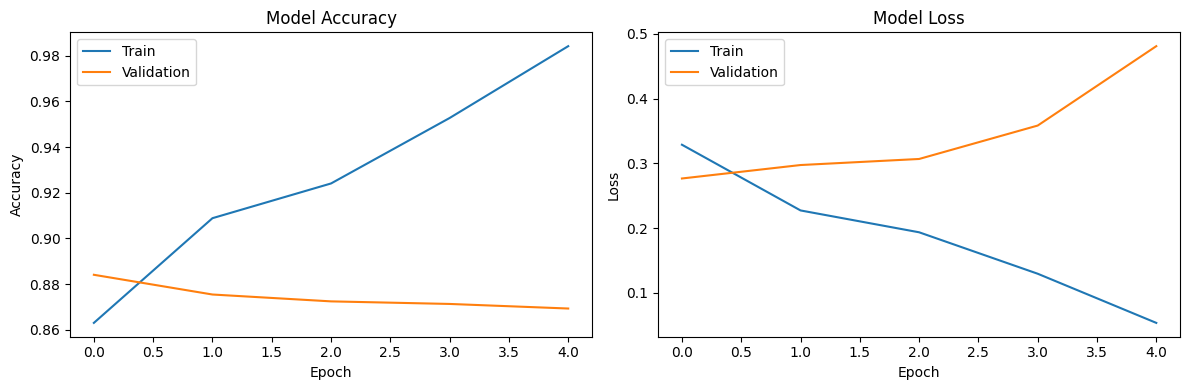

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Download stopwords
nltk.download('stopwords')

# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")

# Preprocessing Function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(preprocess_text)

# Encode the sentiment
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])  # positive=1, negative=0

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_review']).toarray()
y = df['label'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Neural Network Model
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile Model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

# Plot Accuracy & Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
